<a href="https://colab.research.google.com/github/ajaynunna/Major-project---Online-gaming/blob/main/Major_project_Online_gaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topic: Predictive analysis of player engagement and retention.

Dataset : https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset

Research Question: Can player behavioral metrics predict their Engagement Level (High/Medium/Low), and what are the strongest predictors?

Goal: Develop a classification model to accurately predict player engagement for the purpose of improving retention and optimizing game design.


# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Dataset filepath  from github raw data
import pandas as pd
DATA_PATH = 'https://raw.githubusercontent.com/ajaynunna/Major-project---Online-gaming/refs/heads/main/online_gaming_behavior_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

Mounted at /content/drive


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


#Basic Dataset Inspection

In [ ]:
# Basic info of dataset
df.info()

# Summary statistics
df.describe(include='all').T

# Checking missing values
df.isna().sum()

# checking Target distribution
df['EngagementLevel'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


In [ ]:
# Missing value summary table
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent
}).sort_values('missing_count', ascending=False)

missing_df


,missing_count,missing_percent
PlayerID,0,0.0
Age,0,0.0
Gender,0,0.0
Location,0,0.0
GameGenre,0,0.0
PlayTimeHours,0,0.0
InGamePurchases,0,0.0
GameDifficulty,0,0.0
SessionsPerWeek,0,0.0
AvgSessionDurationMinutes,0,0.0


#Exploratory Data Analysis (EDA)

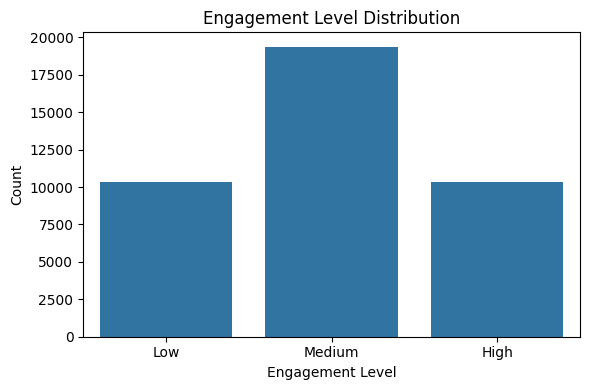

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


In [ ]:
#Engagement Level Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='EngagementLevel', data=df, order=['Low','Medium','High'])
plt.title('Engagement Level Distribution')
plt.ylabel('Count')
plt.xlabel('Engagement Level')
plt.tight_layout()
plt.show()

# numeric counts
print(df['EngagementLevel'].value_counts())

## Feature vs Engagement

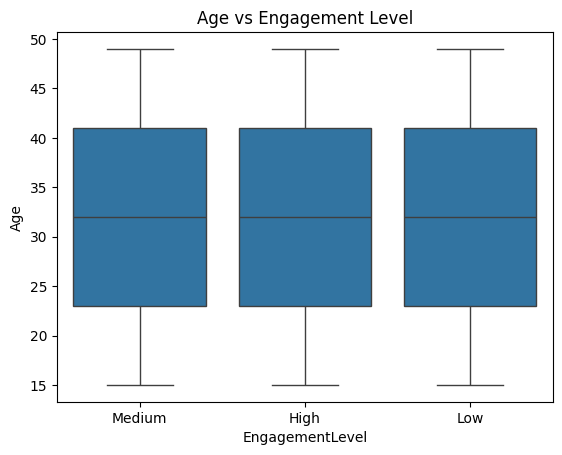

In [ ]:
# Age vs Engagement
sns.boxplot(x='EngagementLevel', y='Age', data=df)
plt.title("Age vs Engagement Level")
plt.show()


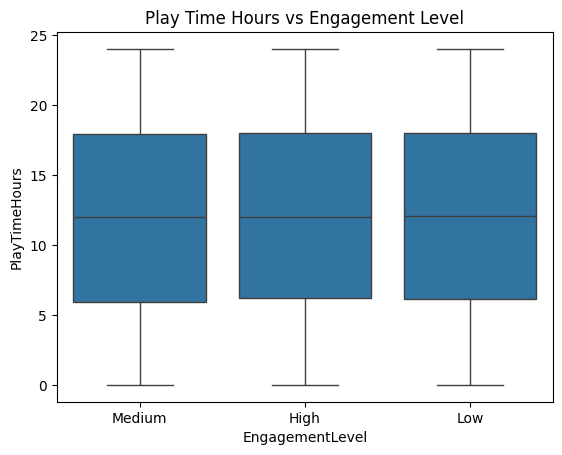

In [ ]:
#Play Time Hours vs Engagement Level

sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=df)
plt.title("Play Time Hours vs Engagement Level")
plt.show()


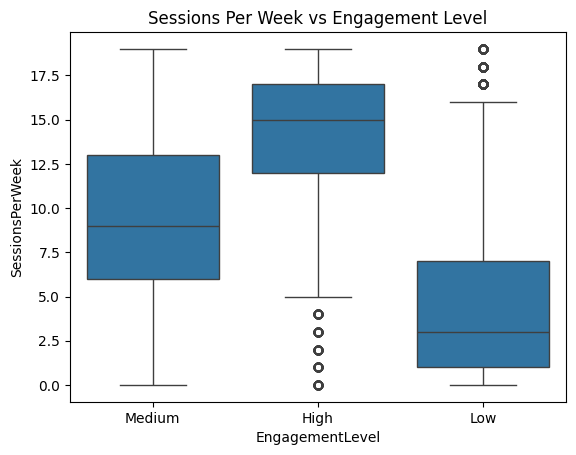

In [ ]:
#Sessions Per Week vs Engagement Level

sns.boxplot(x='EngagementLevel', y='SessionsPerWeek', data=df)
plt.title("Sessions Per Week vs Engagement Level")
plt.show()


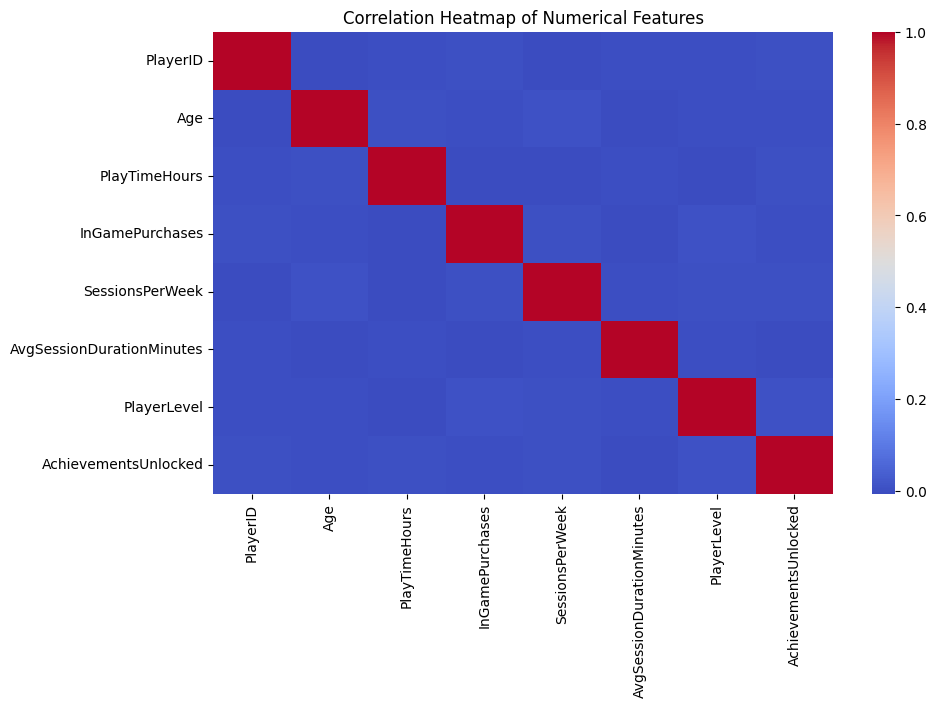

In [ ]:
#relationships between numerical features

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


observation from this heatmap my dataset simply does not contain strong linear relationships between the numerical features

I checked for multicollinearity between features. The correlation heatmap shows that features are not highly correlated, so no feature needed removal due to redundancy.

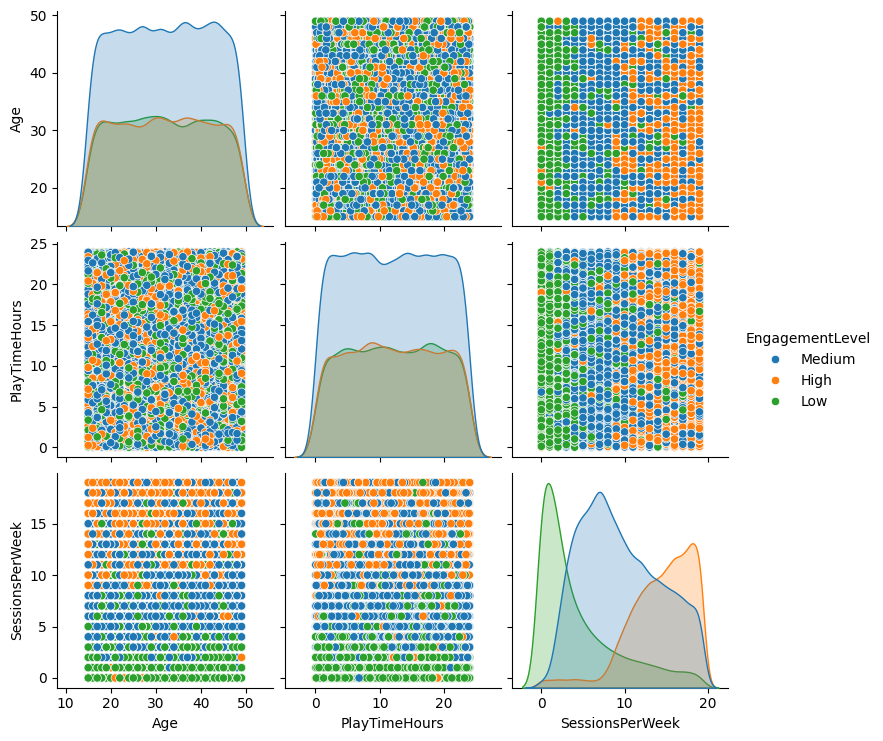

In [ ]:
#full pairplot on 4 features


sns.pairplot(df[['Age','PlayTimeHours','SessionsPerWeek','EngagementLevel']], hue="EngagementLevel")
plt.show()


From the pair plot, I observed overlap among classes. This suggests the dataset is not linearly separable, which is why tree-based models (Random Forest, Gradient Boosting) performed better.

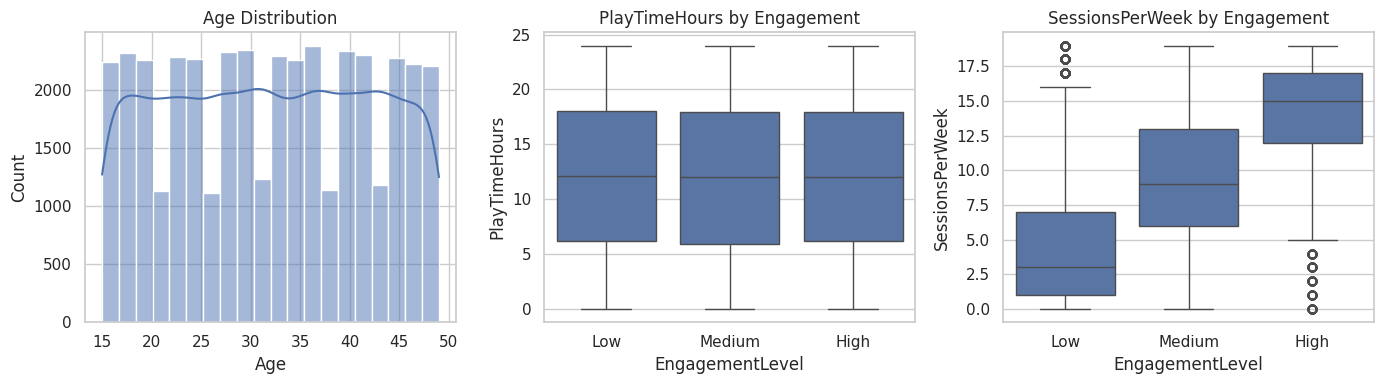

In [ ]:
# Age dist + PlayTimeHours vs Engagement + SessionsPerWeek vs Engagement
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')

plt.subplot(1,3,2)
sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=df, order=['Low','Medium','High'])
plt.title('PlayTimeHours by Engagement')

plt.subplot(1,3,3)
sns.boxplot(x='EngagementLevel', y='SessionsPerWeek', data=df, order=['Low','Medium','High'])
plt.title('SessionsPerWeek by Engagement')

plt.tight_layout()
plt.show()

I performed exploratory data analysis to understand player behavior. The correlation heatmap showed no multicollinearity among numerical features, confirming that each feature provides unique information. Pair plots and boxplots showed overlapping class distributions, explaining why simpler linear models performed worse compared to tree-based models.

# Feature Engineering

In [ ]:
# Feature Engineering must come BEFORE encoding
df['TotalPlayPerWeek'] = df['PlayTimeHours'] * df['SessionsPerWeek']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 17, 25, 40, 60, 100],
    labels=['Teen', 'YoungAdult', 'Adult', 'MidAge', 'Senior']
)

df.head()


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalPlayPerWeek,AgeGroup
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,97.626713,MidAge
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,27.629807,Adult
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,131.580084,YoungAdult
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,47.388161,Adult
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,31.063889,Adult


In [ ]:
X = df.drop("EngagementLevel", axis=1)
y = df["EngagementLevel"]

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_2 = X.select_dtypes(include=['object', 'category']).columns

print("Numerical:", list(numerical_cols))
print("Categorical:", list(categorical_cols_2))


Numerical: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalPlayPerWeek']
Categorical: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'AgeGroup']


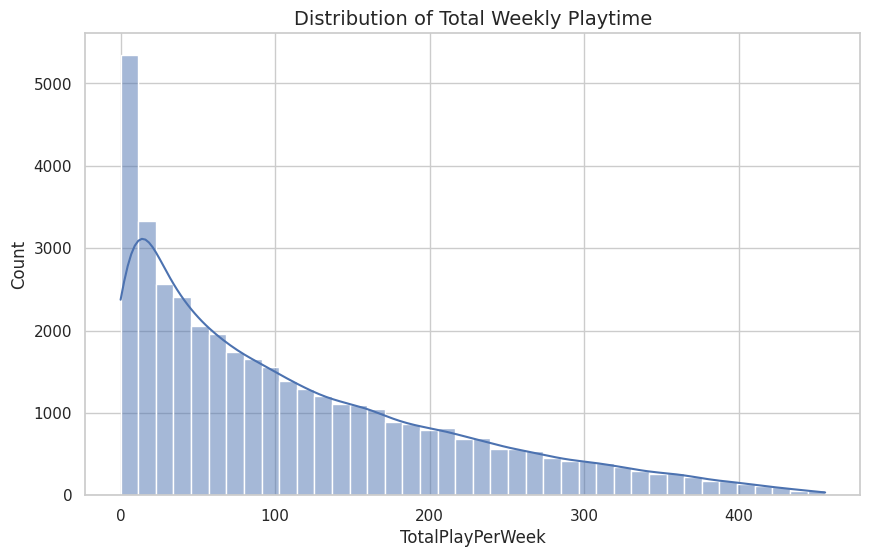

In [ ]:

#Distribution of TotalPlayPerWeek

import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style
sns.set(style="whitegrid")


# Distribution of TotalPlayPerWeek

plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPlayPerWeek'], bins=40, kde=True)
plt.title("Distribution of Total Weekly Playtime", fontsize=14)
plt.xlabel("TotalPlayPerWeek")
plt.ylabel("Count")
plt.show()




/tmp/ipython-input-1285280339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="EngagementLevel", y="TotalPlayPerWeek", palette="Set2")


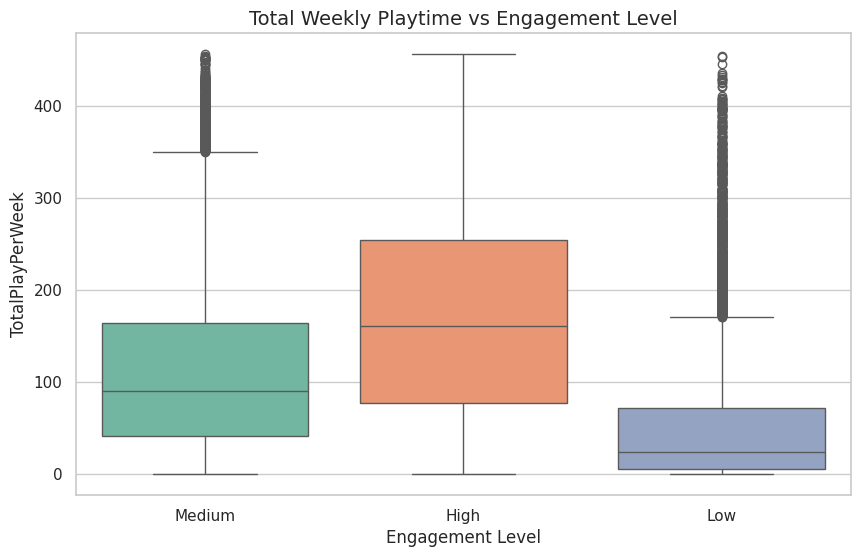

In [ ]:
# TotalPlayPerWeek vs EngagementLevel
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="EngagementLevel", y="TotalPlayPerWeek", palette="Set2")
plt.title("Total Weekly Playtime vs Engagement Level", fontsize=14)
plt.xlabel("Engagement Level")
plt.ylabel("TotalPlayPerWeek")
plt.show()


/tmp/ipython-input-4007868161.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="AgeGroup", palette="Set3")


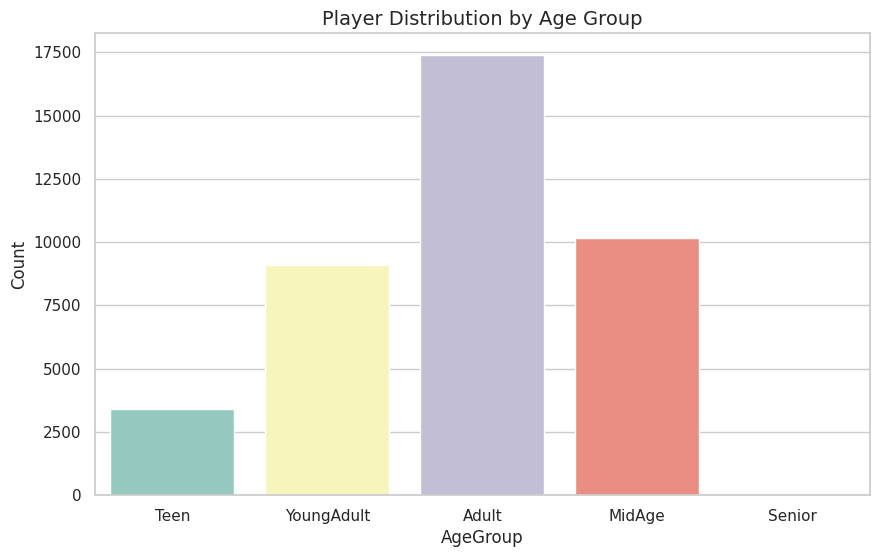

In [ ]:
# Player Count by AgeGroup

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="AgeGroup", palette="Set3")
plt.title("Player Distribution by Age Group", fontsize=14)
plt.xlabel("AgeGroup")
plt.ylabel("Count")
plt.show()


# Encoding + Scaling

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


# Separate X and y

X = df.drop("EngagementLevel", axis=1)
y = df["EngagementLevel"]


#  Identifying Numerical + Categorical Columns


numerical_cols = []
categorical_cols = []

for col in X.columns:
    # Trying to convert to numeric - if it fails, it's categorical
    try:
        pd.to_numeric(X[col], errors='raise')
        numerical_cols.append(col)
    except:
        categorical_cols.append(col)

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)


#  One-Hot Encode categorical columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X)

# Extract encoded feature names
encoded_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

# Final feature names = encoded categorical + numerical
final_feature_names = list(encoded_feature_names) + numerical_cols

print("\nFINAL FEATURE COUNT:", len(final_feature_names))
print("Feature names:", final_feature_names)


# Scale the encoded data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("\nScaled data shape:", X_scaled.shape)


#  Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


print("TRAIN-TEST SPLIT COMPLETE")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())


Numerical Columns: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalPlayPerWeek']
Categorical Columns: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'AgeGroup']

FINAL FEATURE COUNT: 27
Feature names: ['Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'GameDifficulty_Easy', 'GameDifficulty_Hard', 'GameDifficulty_Medium', 'AgeGroup_Adult', 'AgeGroup_MidAge', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalPlayPerWeek']

Scaled data shape: (40034, 27)

TRAIN-TEST SPLIT COMPLETE
Train shape: (32027, 27)
Test shape: (8007, 27)

Train target distribution:
EngagementLevel
Medium    15499
High    

# Model Training and Evaluation

In [ ]:
#  Training All Models and Compare Performance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Dictionary to store predictions
y_preds = {}
# Dictionary to store performance
performance = {}

# Train, predict and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred
    performance[name] = accuracy_score(y_test, y_pred)
    print(f" {name} Accuracy: {performance[name]:.6f}")
    print("\n Classification Report:\n", classification_report(y_test, y_pred))
    print("\n Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-"*60)

# Compare all models in a sorted DataFrame
performance_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Accuracy'])
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)
print("\n Model Performance Comparison:\n")
print(performance_df)


 Logistic Regression Accuracy: 0.821406

 Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.82      0.85      2035
         Low       0.81      0.70      0.75      2093
      Medium       0.80      0.89      0.84      3879

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007


 Confusion Matrix:
[[1672   58  305]
 [  61 1467  565]
 [ 146  295 3438]]
------------------------------------------------------------
 Decision Tree Accuracy: 0.828525

 Classification Report:
               precision    recall  f1-score   support

        High       0.80      0.82      0.81      2035
         Low       0.78      0.80      0.79      2093
      Medium       0.87      0.85      0.86      3879

    accuracy                           0.83      8007
   macro avg       0.82      0.82      0.82      8007
weighted avg       0.83      0.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

def plot_base_model_results(model_name, y_test, y_pred):

    print(f"\nGenerating plots for: {model_name}")


    #  CONFUSION MATRIX


    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Low","Medium","High"],
                yticklabels=["Low","Medium","High"])
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


    #  PRECISION / RECALL / F1


    report = classification_report(y_test, y_pred, output_dict=True)

    # Keeping only classes Low, Medium, High
    df_scores = pd.DataFrame(report).transpose().iloc[:3, :3]

    plt.figure(figsize=(8,4))
    df_scores.plot(kind="bar", figsize=(8,4), colormap="viridis")
    plt.title(f"{model_name} – Precision, Recall & F1-Score")
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.ylim(0,1)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()




Generating plots for: Logistic Regression


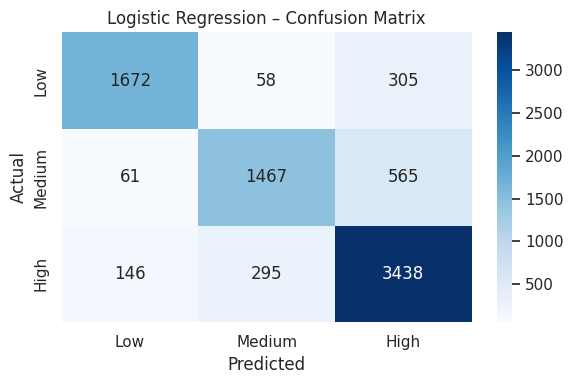

<Figure size 800x400 with 0 Axes>

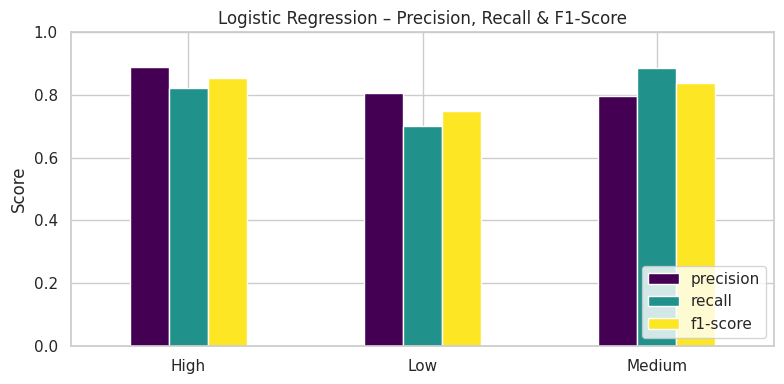


Generating plots for: Decision Tree


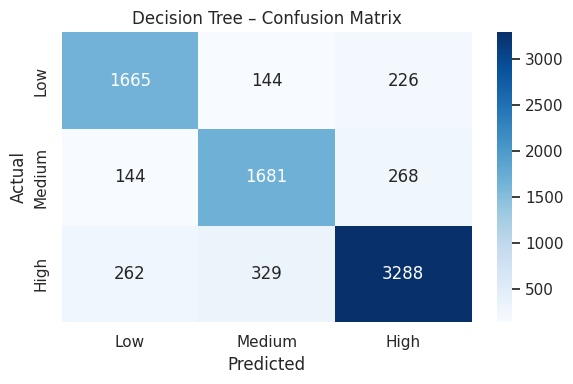

<Figure size 800x400 with 0 Axes>

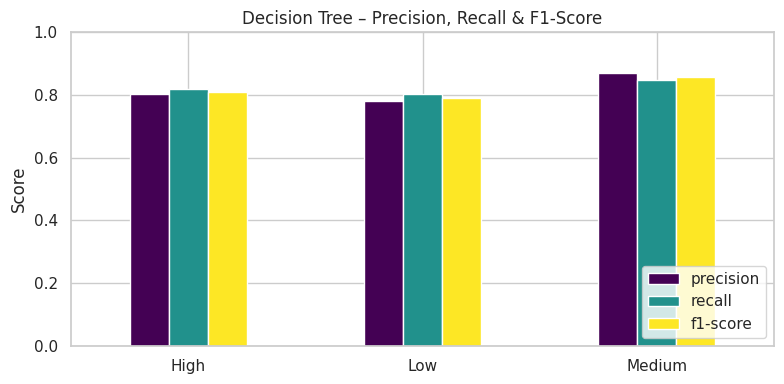


Generating plots for: Random Forest


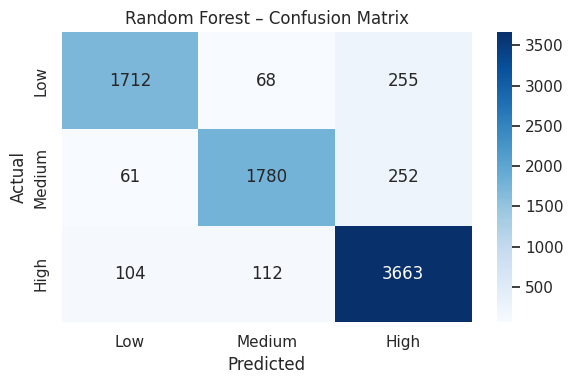

<Figure size 800x400 with 0 Axes>

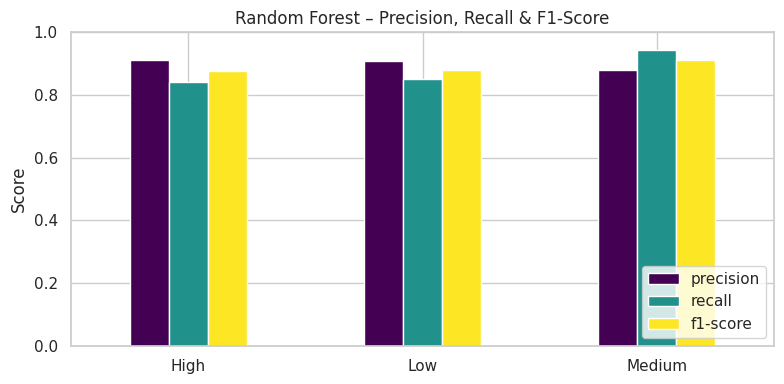


Generating plots for: Gradient Boosting


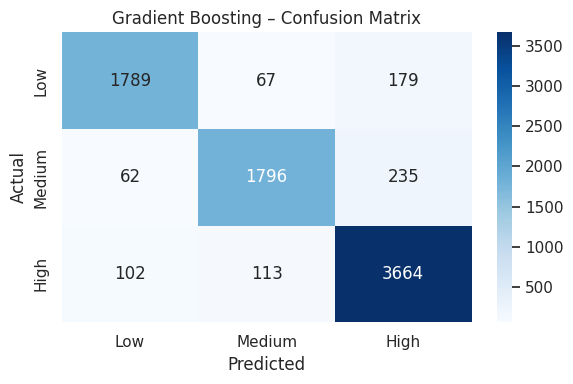

<Figure size 800x400 with 0 Axes>

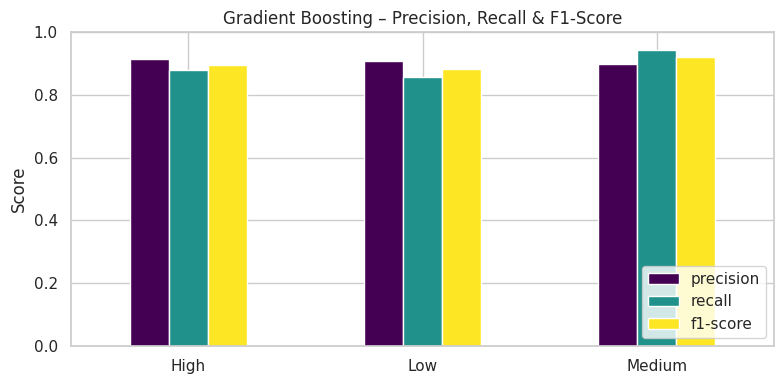


Generating plots for: SVM


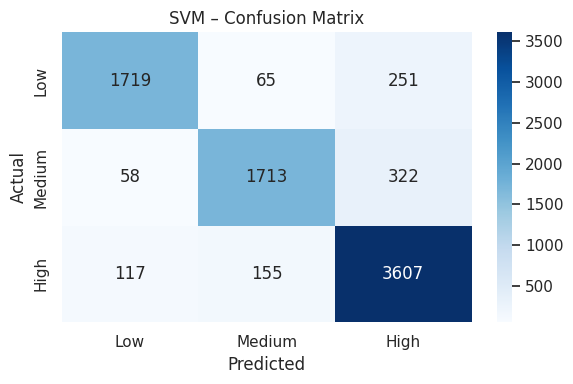

<Figure size 800x400 with 0 Axes>

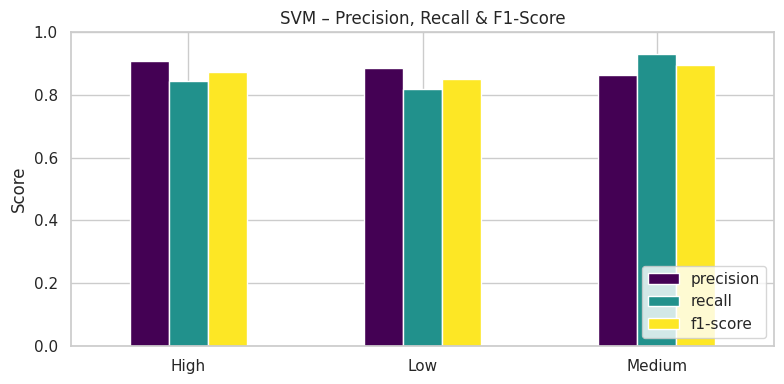

In [ ]:
plot_base_model_results("Logistic Regression", y_test, y_preds["Logistic Regression"])
plot_base_model_results("Decision Tree", y_test, y_preds["Decision Tree"])
plot_base_model_results("Random Forest", y_test, y_preds["Random Forest"])
plot_base_model_results("Gradient Boosting", y_test, y_preds["Gradient Boosting"])
plot_base_model_results("SVM", y_test, y_preds["SVM"])


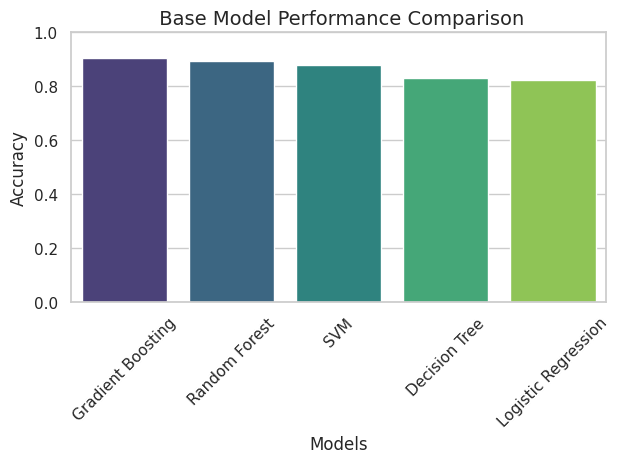

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
colors = sns.color_palette("viridis", len(performance_df))

sns.barplot(
    x=performance_df.index,
    y=performance_df['Accuracy'],
    hue=performance_df.index,
    palette=colors,
    dodge=False,
    legend=False
)

plt.title(" Base Model Performance Comparison", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Hyperparameter tuning

## Logistic Regression with RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Randomized Search
rs_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_grid_lr,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_lr.fit(X_train, y_train)

# Best model
best_lr = rs_lr.best_estimator_

# Predict on test set
y_pred_lr = best_lr.predict(X_test)

# Evaluation
print(" Logistic Regression - Best Parameters:", rs_lr.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\n Classification Report:\n", classification_report(y_test, y_pred_lr))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


 Logistic Regression - Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
 Test Accuracy: 0.8244036468090421

 Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.84      0.86      2067
         Low       0.80      0.70      0.75      2065
      Medium       0.81      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.81      0.82      8007
weighted avg       0.82      0.82      0.82      8007


 Confusion Matrix:
 [[1741   74  252]
 [  62 1452  551]
 [ 185  282 3408]]


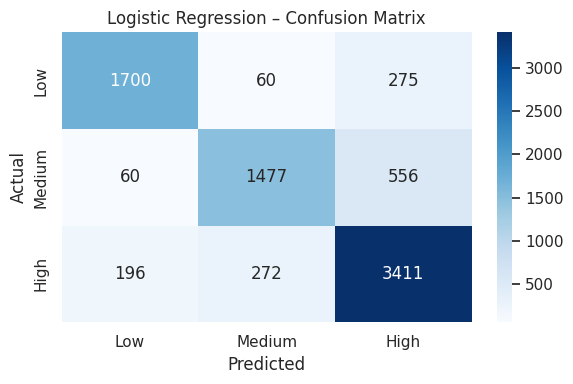

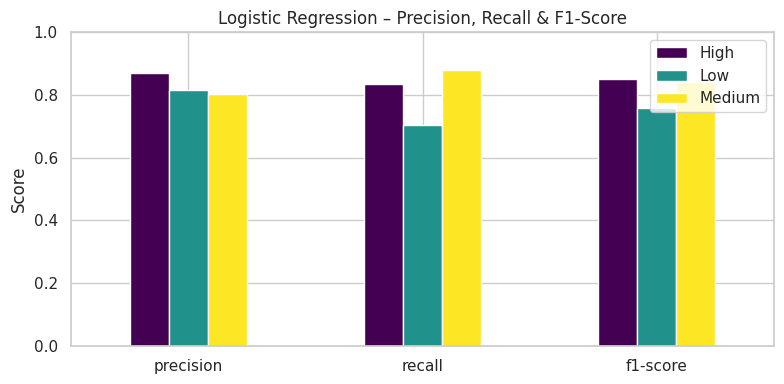

/tmp/ipython-input-3242767286.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[idx], y=feature_names, palette="coolwarm")


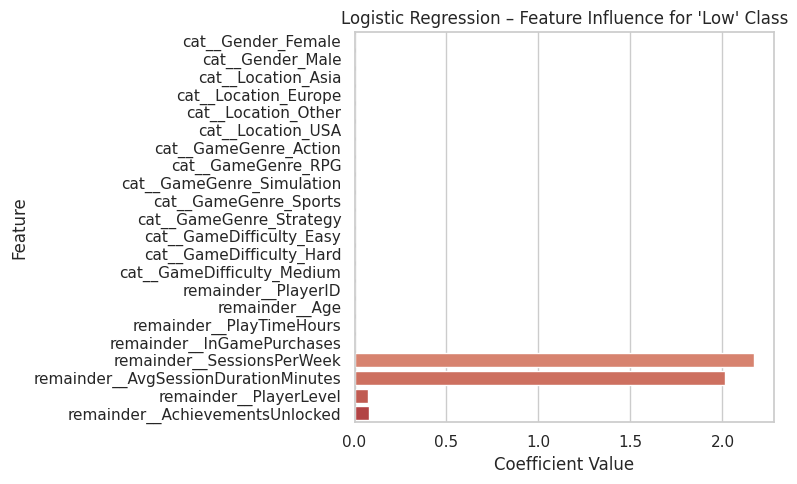

/tmp/ipython-input-3242767286.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[idx], y=feature_names, palette="coolwarm")


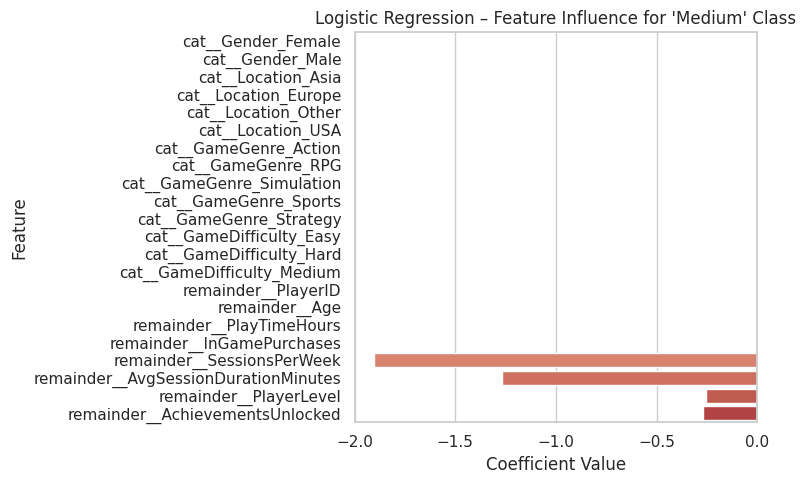

/tmp/ipython-input-3242767286.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[idx], y=feature_names, palette="coolwarm")


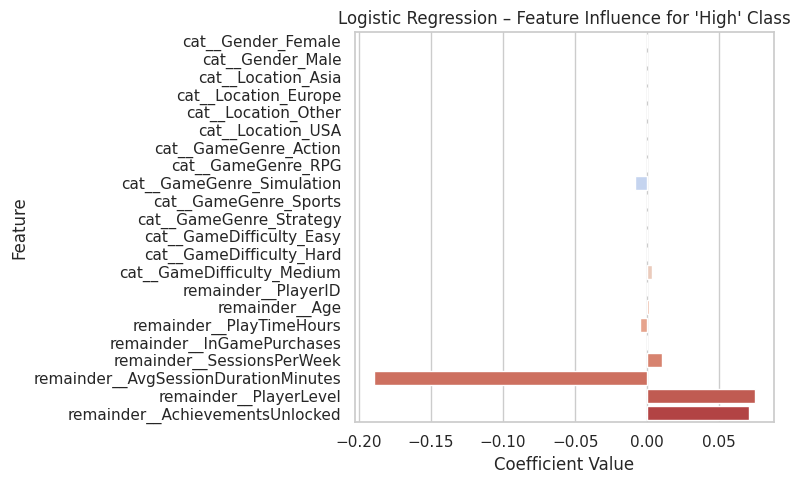

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


#  CONFUSION MATRIX HEATMAP

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# 2 PRECISION / RECALL / F1 BAR PLOT

report = classification_report(y_test, y_pred_lr, output_dict=True)
df_scores = pd.DataFrame(report).iloc[:3, :3]
df_scores.plot(kind="bar", figsize=(8,4), colormap="viridis")
plt.title("Logistic Regression – Precision, Recall & F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



#  COEFFICIENT IMPORTANCE PLOT

# feature names from the encoded + scaled dataset
feature_names = preprocessor.get_feature_names_out()

coefficients = best_lr.coef_

# Logistic Regression gives one set of coefficients PER CLASS (3 classes)
# Plot for each class
for idx, class_name in enumerate(["Low", "Medium", "High"]):
    plt.figure(figsize=(8,5))
    sns.barplot(x=coefficients[idx], y=feature_names, palette="coolwarm")
    plt.title(f"Logistic Regression – Feature Influence for '{class_name}' Class")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [ ]:
# Gradient Boosting with RandomizedSearchCV

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [1.0]
}

# Randomized Search
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_gb.fit(X_train, y_train)

# Best model
best_gb = rs_gb.best_estimator_

# Predict on test set
y_pred_gb = best_gb.predict(X_test)

# Evaluation
print(" Gradient Boosting - Best Parameters:", rs_gb.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\n Classification Report:\n", classification_report(y_test, y_pred_gb))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))




 Gradient Boosting - Best Parameters: {'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.05}
 Test Accuracy: 0.9102035718746098

 Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.87      0.89      2067
         Low       0.91      0.88      0.90      2065
      Medium       0.91      0.95      0.93      3875

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007


 Confusion Matrix:
 [[1801   72  194]
 [  59 1824  182]
 [ 110  102 3663]]


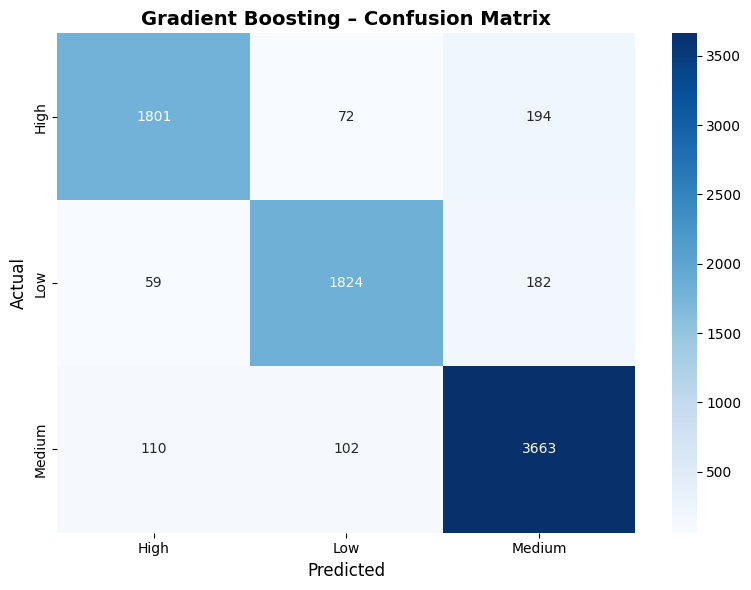

<Figure size 1000x500 with 0 Axes>

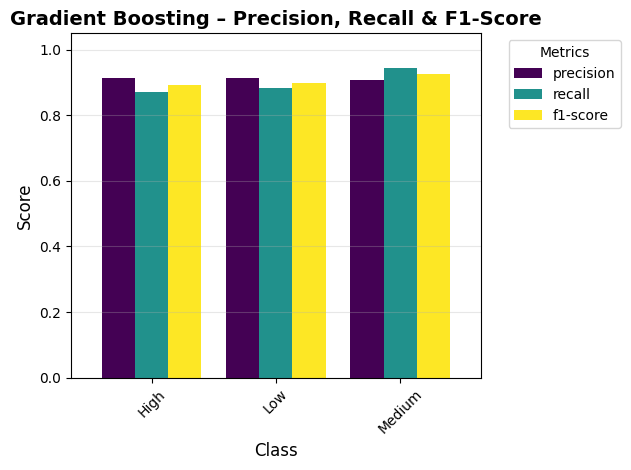

/tmp/ipython-input-3583261697.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances[:top_n], y=sorted_features[:top_n], palette="viridis")


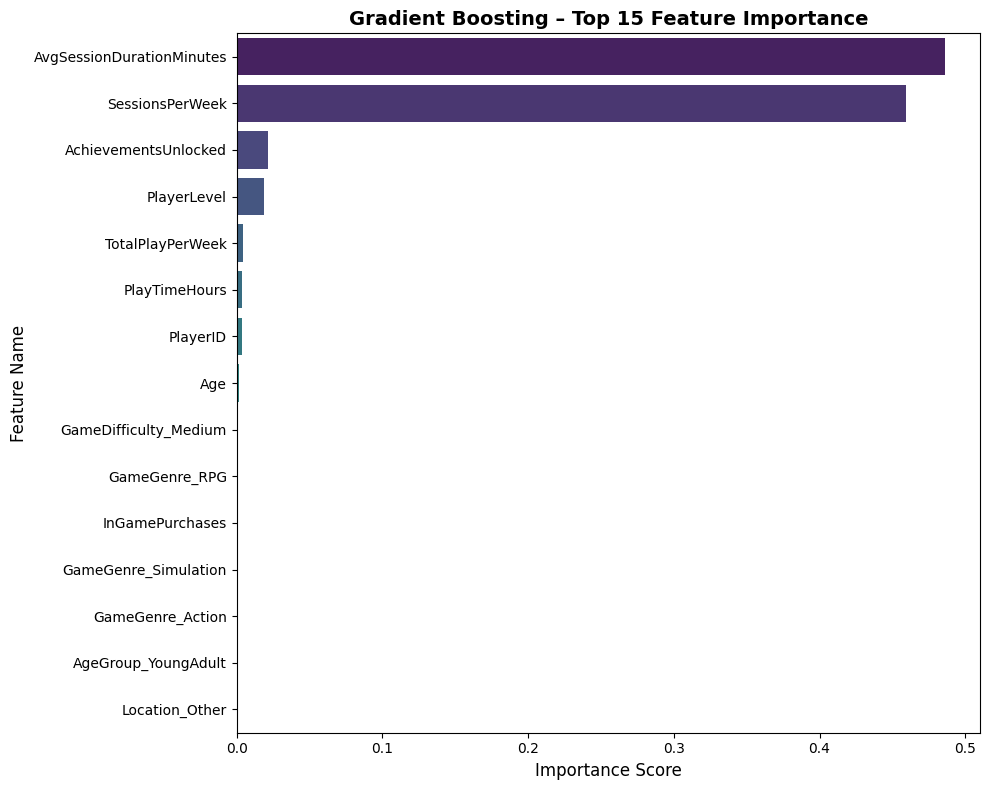

GRADIENT BOOSTING - CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.91      0.87      0.89      2067
         Low       0.91      0.88      0.90      2065
      Medium       0.91      0.95      0.93      3875

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["High", "Low", "Medium"],
            yticklabels=["High", "Low", "Medium"])
plt.title("Gradient Boosting – Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


# PRECISION, RECALL, F1-SCORE

report = classification_report(y_test, y_pred_gb, output_dict=True)
df_scores = pd.DataFrame(report).iloc[:3, :3].T

plt.figure(figsize=(10, 5))
df_scores.plot(kind="bar", colormap="viridis", width=0.8)
plt.title("Gradient Boosting – Precision, Recall & F1-Score", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Class", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# FEATURE IMPORTANCE

importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

# final_feature_names from preprocessing
sorted_features = np.array(final_feature_names)[indices]
sorted_importances = importances[indices]

# top 15 features
top_n = 15
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importances[:top_n], y=sorted_features[:top_n], palette="viridis")
plt.title(f"Gradient Boosting – Top {top_n} Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:
#  Random Forest with RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  Parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    error_score='raise',
    verbose=1
)

# Fit the model
rs_rf.fit(X_train, y_train)

# Best model
best_rf = rs_rf.best_estimator_

# Predict on test data
y_pred_rf = best_rf.predict(X_test)

# Evaluation
print("\n Random Forest - Best Parameters:", rs_rf.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Fitting 3 folds for each of 5 candidates, totalling 15 fits

 Random Forest - Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40}
 Test Accuracy: 0.8940926689146996

 Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.83      0.87      2067
         Low       0.91      0.86      0.88      2065
      Medium       0.88      0.94      0.91      3875

    accuracy                           0.89      8007
   macro avg       0.90      0.88      0.89      8007
weighted avg       0.90      0.89      0.89      8007


 Confusion Matrix:
 [[1722   70  275]
 [  56 1777  232]
 [ 109  106 3660]]


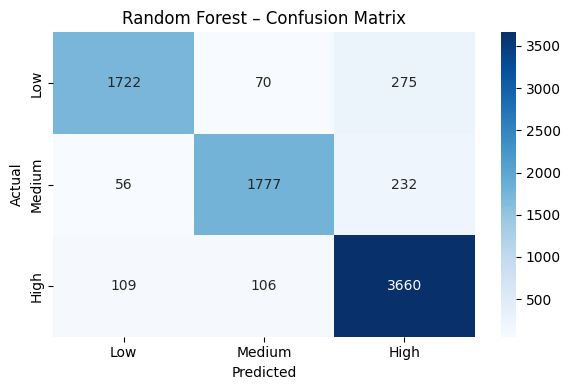

<Figure size 800x400 with 0 Axes>

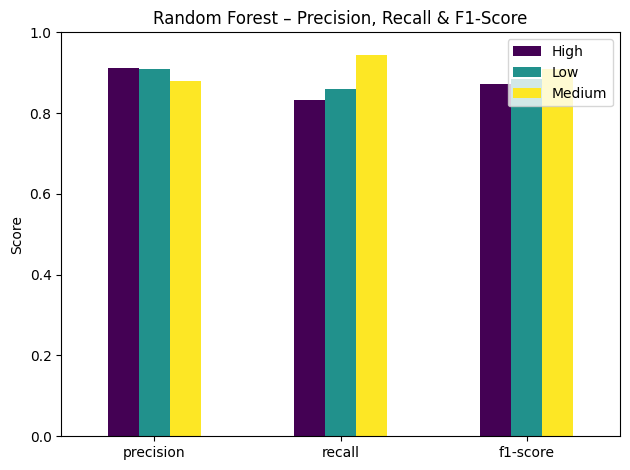

/tmp/ipython-input-4082982538.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


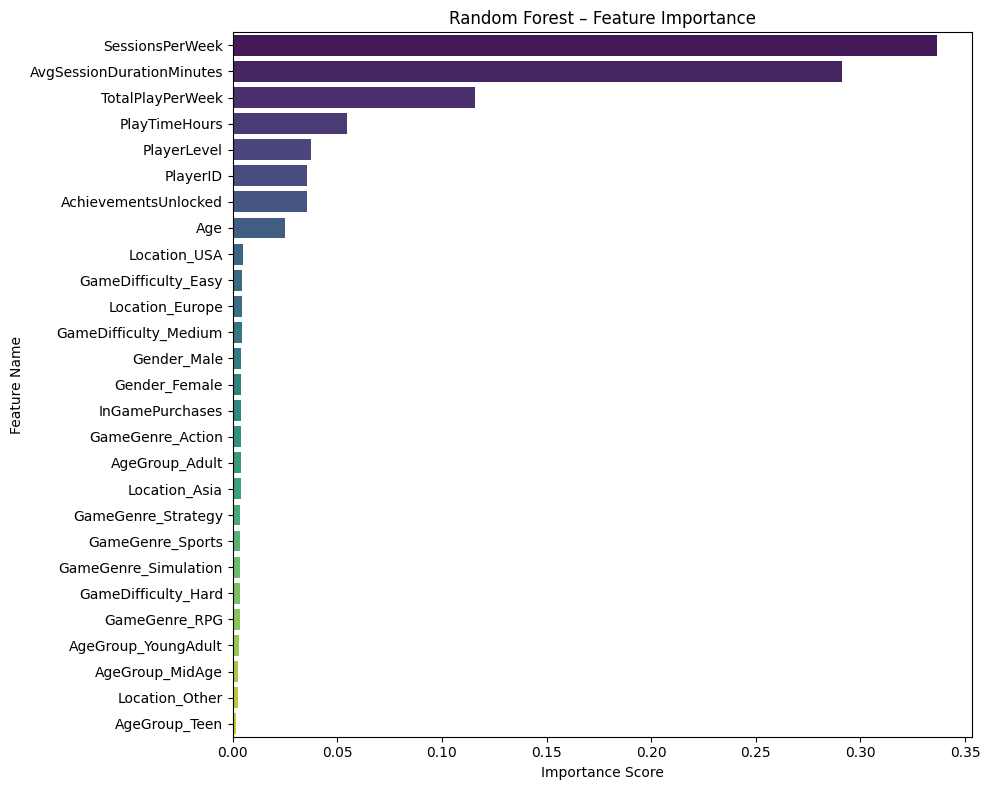

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



# PRECISION, RECALL, F1

report = classification_report(y_test, y_pred_rf, output_dict=True)
df_scores = pd.DataFrame(report).iloc[:3, :3]

plt.figure(figsize=(8,4))
df_scores.plot(kind="bar", colormap="viridis")
plt.title("Random Forest – Precision, Recall & F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



# FEATURE IMPORTANCE

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Convert final feature names to numpy array for proper indexing
final_feature_names_np = np.array(final_feature_names)

sorted_features = final_feature_names_np[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10,8))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title("Random Forest – Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


In [ ]:
#SVM with RandomizedSearchCV

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Randomized Search
rs_svm = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_grid_svm,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_svm.fit(X_train, y_train)

# Best model
best_svm = rs_svm.best_estimator_

# Predict on test set
y_pred_svm = best_svm.predict(X_test)

# Evaluation
print(" SVM - Best Parameters:", rs_svm.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\n Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


 SVM - Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
 Test Accuracy: 0.8536280754339952

 Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.82      0.87      2067
         Low       0.87      0.74      0.80      2065
      Medium       0.82      0.93      0.87      3875

    accuracy                           0.85      8007
   macro avg       0.87      0.83      0.85      8007
weighted avg       0.86      0.85      0.85      8007


 Confusion Matrix:
 [[1702   63  302]
 [  57 1518  490]
 [  97  163 3615]]


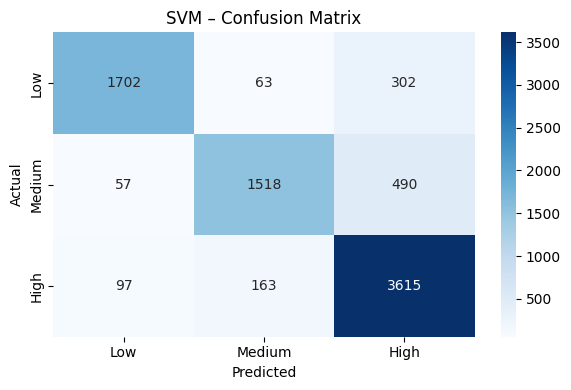

<Figure size 800x400 with 0 Axes>

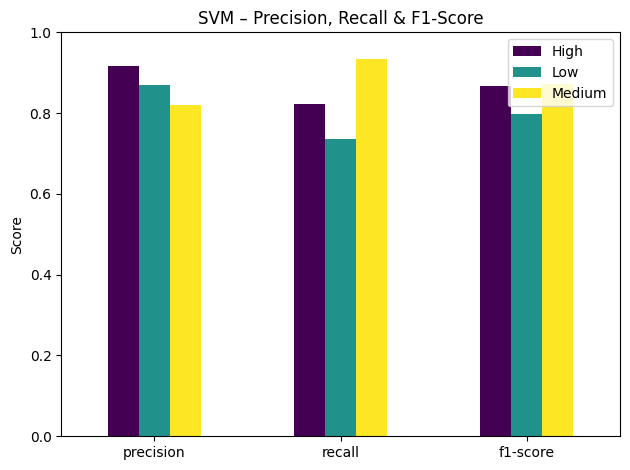

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report



#  CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("SVM – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



#  PRECISION, RECALL, F1 BAR CHART

report = classification_report(y_test, y_pred_svm, output_dict=True)
df_scores = pd.DataFrame(report).iloc[:3, :3]

plt.figure(figsize=(8,4))
df_scores.plot(kind="bar", colormap="viridis")
plt.title("SVM – Precision, Recall & F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# Decision Tree with RandomizedSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'splitter': ['best', 'random']
}

# RandomizedSearchCV
rs_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid_dt,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit model
rs_dt.fit(X_train, y_train)

# Best model
best_dt = rs_dt.best_estimator_

# Predict
y_pred_dt = best_dt.predict(X_test)

# Evaluation
print(" Decision Tree - Best Parameters:", rs_dt.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\n Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


 Decision Tree - Best Parameters: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'gini'}
 Test Accuracy: 0.8776070937929312

 Classification Report:
               precision    recall  f1-score   support

        High       0.86      0.86      0.86      2067
         Low       0.85      0.85      0.85      2065
      Medium       0.90      0.90      0.90      3875

    accuracy                           0.88      8007
   macro avg       0.87      0.87      0.87      8007
weighted avg       0.88      0.88      0.88      8007


 Confusion Matrix:
 [[1786  105  176]
 [ 105 1763  197]
 [ 186  211 3478]]


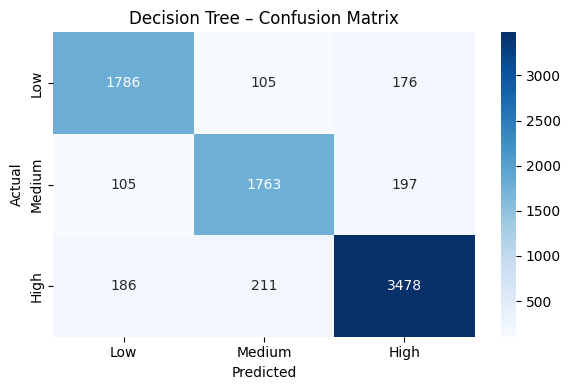

<Figure size 800x400 with 0 Axes>

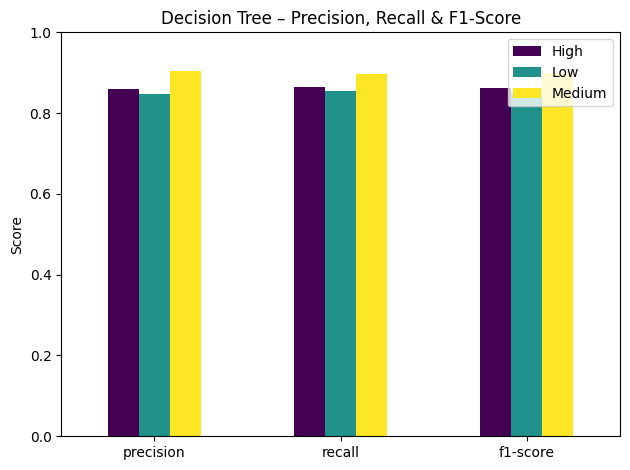

/tmp/ipython-input-1892528895.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


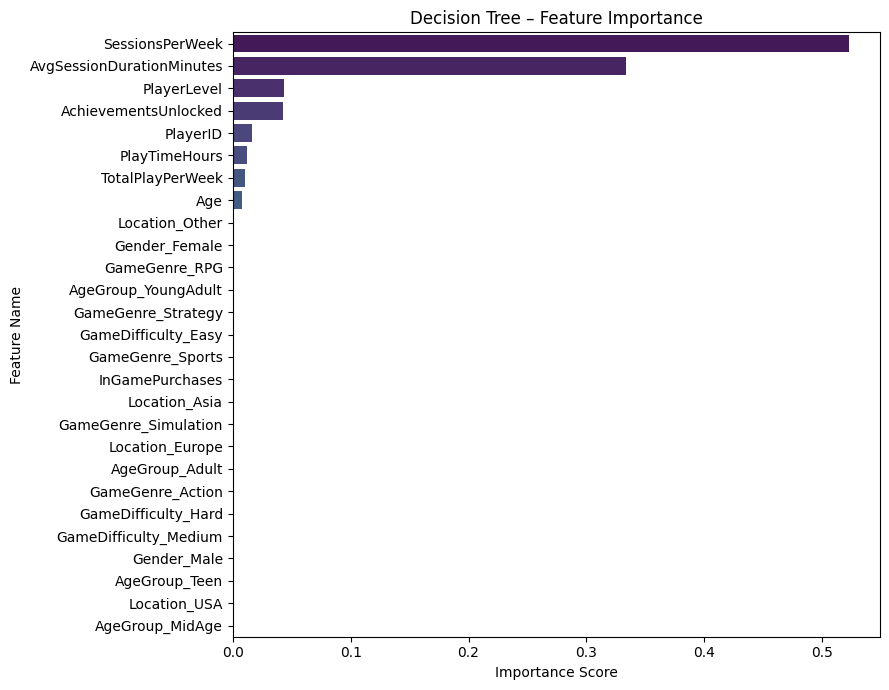

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


#   CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("Decision Tree – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



#   PRECISION / RECALL / F1 BAR PLOT


report = classification_report(y_test, y_pred_dt, output_dict=True)
df_scores = pd.DataFrame(report).iloc[:3, :3]

plt.figure(figsize=(8,4))
df_scores.plot(kind="bar", colormap="viridis")
plt.title("Decision Tree – Precision, Recall & F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




#  FEATURE IMPORTANCE


importances = best_dt.feature_importances_

#  final feature names (27)
feature_names = final_feature_names

# Sort importances
indices = np.argsort(importances)[::-1]
sorted_features = np.array(feature_names)[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(9,7))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title("Decision Tree – Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


#Compare All Optimized Model Performances

 Optimized Model Performance Comparison:

                     Test Accuracy
Gradient Boosting         0.910204
Random Forest             0.894093
Decision Tree             0.877607
SVM                       0.853628
Logistic Regression       0.824404


/tmp/ipython-input-1772142762.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_df.index, y=performance_df['Test Accuracy'], palette="viridis")


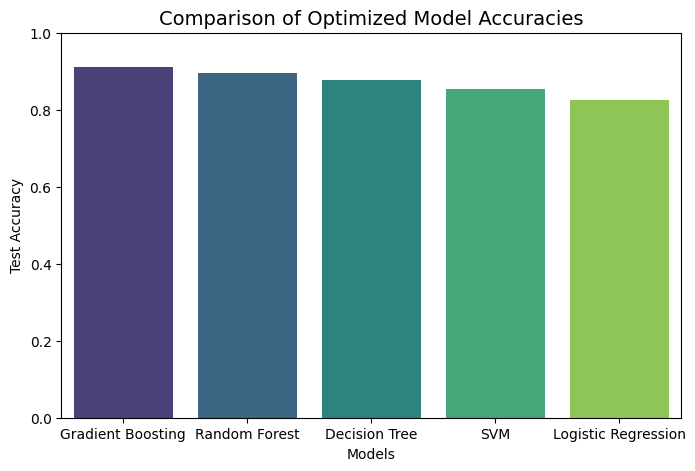

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Collect test accuracies
performance = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

# Create a DataFrame for easy viewing
performance_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Test Accuracy'])
performance_df = performance_df.sort_values(by='Test Accuracy', ascending=False)

print(" Optimized Model Performance Comparison:\n")
print(performance_df)

#  Visualize with a bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=performance_df.index, y=performance_df['Test Accuracy'], palette="viridis")
plt.title("Comparison of Optimized Model Accuracies", fontsize=14)
plt.ylabel("Test Accuracy")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.show()



========== FINAL MODEL PERFORMANCE ==========

                 Model  Base Accuracy  Tuned Accuracy  Improvement (%)
0  Logistic Regression       0.821406        0.824404             0.30
1        Decision Tree       0.828525        0.877607             4.91
2        Random Forest       0.893593        0.894093             0.05
3    Gradient Boosting       0.905333        0.910204             0.49
4                  SVM       0.879106        0.853628            -2.55


/tmp/ipython-input-2844003759.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


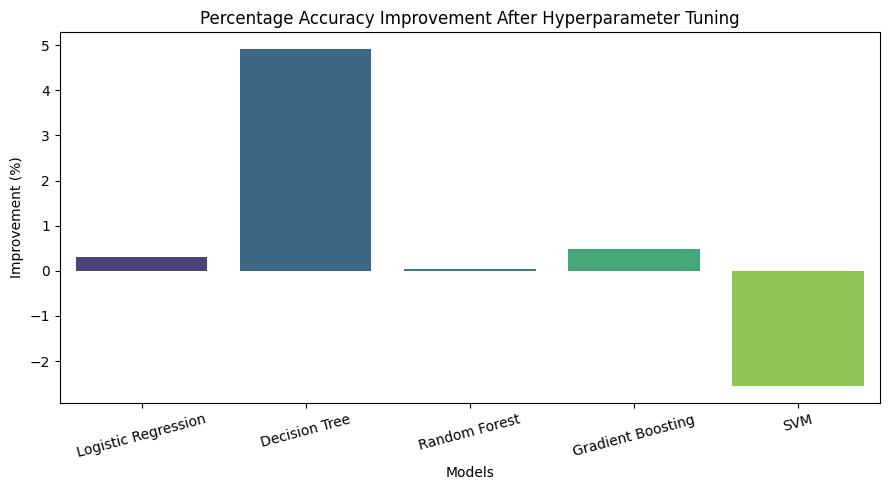

 FINAL SELECTED MODEL: *Gradient Boosting*
 BEST ACCURACY ACHIEVED: *0.9102*


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  FINAL PERFORMANCE TABLE

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "SVM"],
    "Base Accuracy": [
        0.821406,   # logistic base
        0.828525,   # dt base
        0.893593,   # rf base
        0.905333,   # gb base
        0.879106    # svm base
    ],
    "Tuned Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

# Percentage improvement
final_results["Improvement (%)"] = (
    (final_results["Tuned Accuracy"] - final_results["Base Accuracy"]) * 100
).round(2)

print("\n========== FINAL MODEL PERFORMANCE ==========\n")
print(final_results)



#  IMPROVEMENT PLOT

plt.figure(figsize=(9,5))
sns.barplot(
    x="Model",
    y="Improvement (%)",
    data=final_results,
    palette="viridis"
)
plt.title("Percentage Accuracy Improvement After Hyperparameter Tuning")
plt.ylabel("Improvement (%)")
plt.xlabel("Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


#  FINAL BEST MODEL SELECTION

best_model_name = final_results.loc[
    final_results["Tuned Accuracy"].idxmax(), "Model"
]

best_model_score = final_results["Tuned Accuracy"].max()

print(f" FINAL SELECTED MODEL: *{best_model_name}*")
print(f" BEST ACCURACY ACHIEVED: *{best_model_score:.4f}*")



/tmp/ipython-input-3480750094.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances[:15], y=sorted_features[:15], palette="viridis")


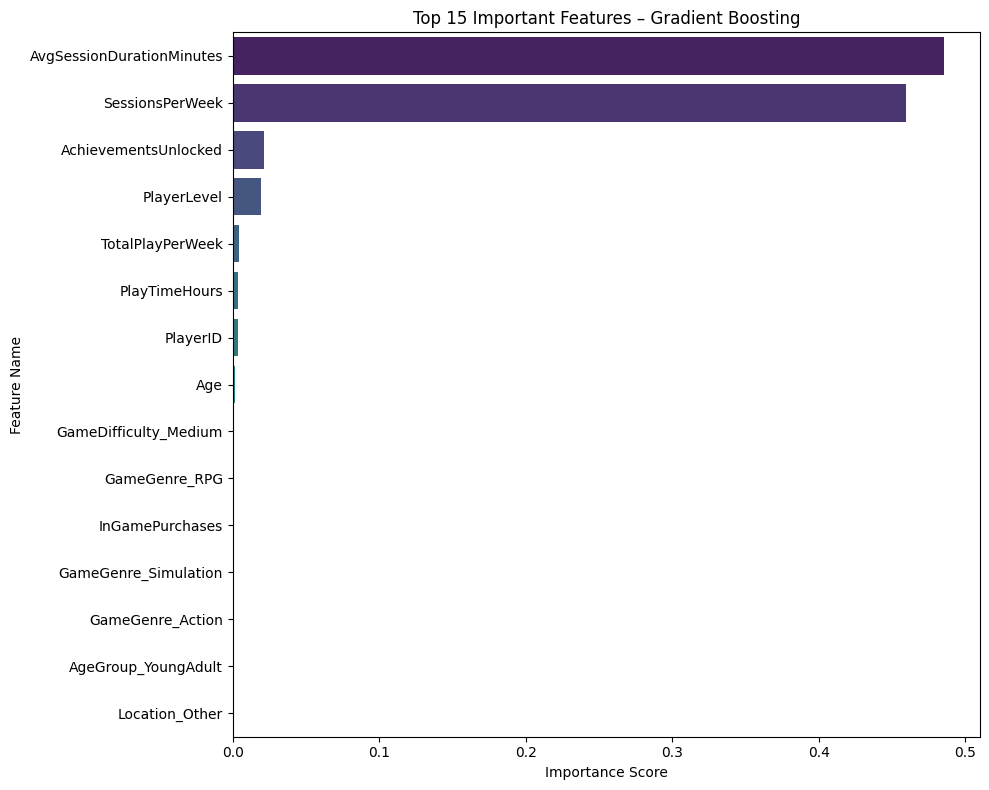

In [ ]:

#  Feature Importance for BEST MODEL (GB)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Feature names
feature_names = final_feature_names

# Feature importances
importances = best_gb.feature_importances_

# Sort descending
indices = np.argsort(importances)[::-1]

sorted_features = np.array(feature_names)[indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importances[:15], y=sorted_features[:15], palette="viridis")
plt.title("Top 15 Important Features – Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()
